# Task 1: Dataset Understanding

In [12]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
# Upload Dataset File
from google.colab import files

uploaded = files.upload()

Saving customer_support_text_classification.csv to customer_support_text_classification (1).csv


In [14]:
# Load Dataset
df = pd.read_csv("customer_support_text_classification.csv")

In [15]:
# Display First 5 Rows
df.head()

,ticket_id,channel,customer_message,sentiment_label,word_count,urgent_flag
0,TKT00001,chat,I need information about the payment process. ...,neutral,18,1
1,TKT00002,phone,I need information about the payment process.,neutral,7,0
2,TKT00003,email,The refund process was fast and convenient. I ...,positive,12,0
3,TKT00004,social,My refund is still pending and this experience...,negative,15,1
4,TKT00005,chat,Please tell me how to update my account details.,neutral,9,0


In [16]:
# Number of Rows and Columns
print("Dataset Shape:", df.shape)

Dataset Shape: (1500, 6)


In [17]:
# Display Column Names
print(df.columns)

Index(['ticket_id', 'channel', 'customer_message', 'sentiment_label',
       'word_count', 'urgent_flag'],
      dtype='object')


In [18]:
# Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   ticket_id         1500 non-null   object
 1   channel           1500 non-null   object
 2   customer_message  1500 non-null   object
 3   sentiment_label   1500 non-null   object
 4   word_count        1500 non-null   int64 
 5   urgent_flag       1500 non-null   int64 
dtypes: int64(2), object(4)
memory usage: 70.4+ KB


In [19]:
# Missing Values Check
print(df.isnull().sum())

ticket_id           0
channel             0
customer_message    0
sentiment_label     0
word_count          0
urgent_flag         0
dtype: int64


In [21]:
print(df.columns)

Index(['ticket_id', 'channel', 'customer_message', 'sentiment_label',
       'word_count', 'urgent_flag'],
      dtype='object')


In [22]:
# Display Sample Text Records
print(df["customer_message"].head())

0    I need information about the payment process. ...
1        I need information about the payment process.
2    The refund process was fast and convenient. I ...
3    My refund is still pending and this experience...
4     Please tell me how to update my account details.
Name: customer_message, dtype: object


In [23]:
# Display Target Labels
print(df["sentiment_label"].unique())

['neutral' 'positive' 'negative']


In [24]:
# Class Distribution
print(df["sentiment_label"].value_counts())

sentiment_label
neutral     524
negative    497
positive    479
Name: count, dtype: int64


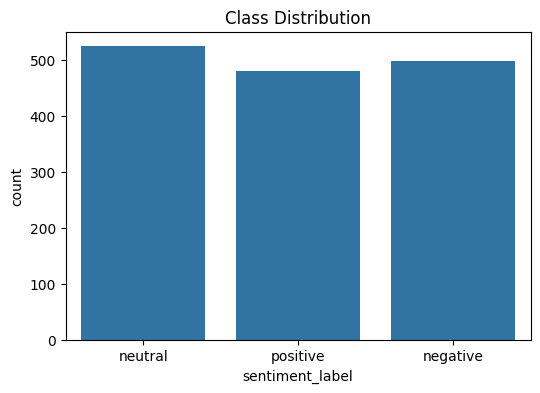

In [25]:
# Plot Class Distribution
plt.figure(figsize=(6,4))

sns.countplot(x=df["sentiment_label"])

plt.title("Class Distribution")

plt.show()

In [26]:
# Calculate Text Length
df["text_length"] = df["customer_message"].apply(len)

# Average Text Length
print("Average Text Length:", df["text_length"].mean())

Average Text Length: 72.75666666666666


In [27]:
# Display Text Length Samples
df[["customer_message", "text_length"]].head()

,customer_message,text_length
0,I need information about the payment process. ...,108
1,I need information about the payment process.,45
2,The refund process was fast and convenient. I ...,76
3,My refund is still pending and this experience...,89
4,Please tell me how to update my account details.,48


# Task 2: Text Preprocessing

In [35]:
# Import Required Libraries
import re
import nltk

from nltk.corpus import stopwords

from nltk.tokenize import word_tokenize

In [36]:
# Download Required NLTK Files
nltk.download('punkt')

nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [37]:
# Convert Text to Lowercase
df["clean_text"] = df["customer_message"].str.lower()

In [38]:
# Remove Special Characters
df["clean_text"] = df["clean_text"].apply(
    lambda x: re.sub(r'[^a-zA-Z\s]', '', x)
)

In [39]:
import nltk

nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [40]:
# Tokenization
df["tokens"] = df["clean_text"].apply(word_tokenize)

In [41]:
# Load Stopwords
stop_words = set(stopwords.words('english'))

# Remove Stopwords
df["tokens"] = df["tokens"].apply(
    lambda words: [word for word in words if word not in stop_words]
)

In [42]:
# Join Tokens Back into Sentence
df["processed_text"] = df["tokens"].apply(
    lambda words: " ".join(words)
)

In [44]:
# Display Processed Text
df[[
    "customer_message",
    "processed_text"
]].head()

,customer_message,processed_text
0,I need information about the payment process. ...,need information payment process ticket number...
1,I need information about the payment process.,need information payment process
2,The refund process was fast and convenient. I ...,refund process fast convenient appreciate quic...
3,My refund is still pending and this experience...,refund still pending experience frustrating ti...
4,Please tell me how to update my account details.,please tell update account details


In [45]:
# Import Tokenizer
from tensorflow.keras.preprocessing.text import Tokenizer

In [46]:
# Create Tokenizer
tokenizer = Tokenizer(num_words=5000)

tokenizer.fit_on_texts(df["processed_text"])

In [47]:
# Convert Text to Sequences
sequences = tokenizer.texts_to_sequences(
    df["processed_text"]
)

In [48]:
# Import Padding
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [49]:
# Pad Sequences
padded_sequences = pad_sequences(
    sequences,
    maxlen=50,
    padding='post',
    truncating='post'
)

In [50]:
# Display Shape
print(padded_sequences.shape)

(1500, 50)


# Task 3: Text Vectorization

In [51]:
# Import TF-IDF Vectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

In [52]:
# Create TF-IDF Vectorizer
tfidf = TfidfVectorizer(max_features=5000)

In [53]:
# Convert Text into TF-IDF Vectors
X = tfidf.fit_transform(df["processed_text"])

In [54]:
# Define Target Variable
y = df["sentiment_label"]

In [55]:
# Display TF-IDF Shape
print("TF-IDF Matrix Shape:", X.shape)

TF-IDF Matrix Shape: (1500, 146)


In [56]:
# Display Sample TF-IDF Feature Names
print(tfidf.get_feature_names_out()[:20])

['account' 'activate' 'ago' 'analytics' 'app' 'appreciate' 'arrived'
 'assigned' 'available' 'bad' 'billing' 'call' 'cancel' 'care' 'charged'
 'checking' 'clear' 'communication' 'completed' 'confirm']


# Task 4: Baseline Model

In [57]:
# Import Required Libraries
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [59]:
# Split Dataset into Training and Testing Sets
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42
)

In [60]:
# Create Logistic Regression Model
model = LogisticRegression()

In [61]:
# Train the Model
model.fit(X_train, y_train)

LogisticRegression()

In [62]:
# Predict on Test Data
y_pred = model.predict(X_test)

In [63]:
# Model Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 1.0


In [64]:
# Classification Report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    negative       1.00      1.00      1.00       109
     neutral       1.00      1.00      1.00       104
    positive       1.00      1.00      1.00        87

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



In [65]:
# Create Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[109   0   0]
 [  0 104   0]
 [  0   0  87]]


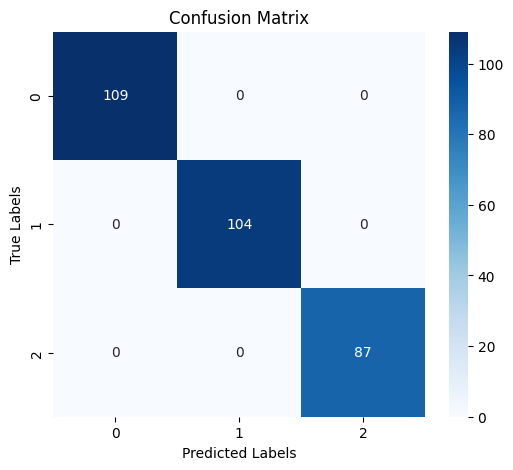

In [66]:
# Plot Confusion Matrix
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted Labels")

plt.ylabel("True Labels")

plt.show()

In [67]:
# Display Sample Predictions
sample_predictions = pd.DataFrame({

    "Actual Label": y_test.values,

    "Predicted Label": y_pred
})

sample_predictions.head(10)

,Actual Label,Predicted Label
0,neutral,neutral
1,positive,positive
2,neutral,neutral
3,negative,negative
4,negative,negative
5,negative,negative
6,negative,negative
7,neutral,neutral
8,negative,negative
9,negative,negative


# Task 5: Sequence Model or Conceptual Architecture

In [68]:
# Import Required Libraries
from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Embedding
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dense

In [69]:
# Encode Target Labels
encoder = LabelEncoder()

y_encoded = encoder.fit_transform(df["sentiment_label"])

In [79]:
# Split NLP Sequence Dataset
X_train_seq, X_test_seq, y_train_seq, y_test_seq = train_test_split(

    padded_sequences,

    y_encoded,

    test_size=0.2,

    random_state=42
)

In [80]:
# Create LSTM Model
lstm_model = Sequential()

In [81]:
# Add Embedding Layer
lstm_model.add(

    Embedding(
        input_dim=5000,
        output_dim=64,
        input_length=50
    )
)

In [82]:
# Add LSTM Layer
lstm_model.add(

    LSTM(64)
)

In [83]:
# Add Output Layer
lstm_model.add(

    Dense(
        len(df["sentiment_label"].unique()),

        activation='softmax'
    )
)

In [84]:
# Compile Model
lstm_model.compile(

    optimizer='adam',

    loss='sparse_categorical_crossentropy',

    metrics=['accuracy']
)

In [85]:
# Display Model Summary
lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [86]:
# Train LSTM Model
history = lstm_model.fit(

    X_train_seq,

    y_train_seq,

    epochs=5,

    batch_size=32,

    validation_data=(X_test_seq, y_test_seq)
)

Epoch 1/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 8s 48ms/step - accuracy: 0.3358 - loss: 1.1013 - val_accuracy: 0.3467 - val_loss: 1.0970
Epoch 2/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.3375 - loss: 1.1001 - val_accuracy: 0.3467 - val_loss: 1.1005
Epoch 3/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.3500 - loss: 1.0986 - val_accuracy: 0.3467 - val_loss: 1.0985
Epoch 4/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.3500 - loss: 1.0983 - val_accuracy: 0.3467 - val_loss: 1.0997
Epoch 5/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.3500 - loss: 1.0986 - val_accuracy: 0.3467 - val_loss: 1.0996


In [87]:
# Evaluate Model
loss, accuracy = lstm_model.evaluate(

    X_test_seq,

    y_test_seq
)

print("Test Loss:", loss)

print("Test Accuracy:", accuracy)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.3467 - loss: 1.0996
Test Loss: 1.0995564460754395
Test Accuracy: 0.3466666638851166


# Task 6: Attention and Transformer Reflection

## Why RNNs Struggle with Long-Term Dependencies

RNNs process text sequentially, but they often struggle to remember information from earlier parts of long sequences.  
As sequence length increases, important information can gradually disappear due to the vanishing gradient problem.

---

## How LSTMs Help with Memory

LSTMs improve traditional RNNs by using memory cells and gating mechanisms.  
These gates help the model decide what information to keep, update, or forget, allowing LSTMs to retain important long-term information more effectively.

---

## What Attention Solves in Sequence-to-Sequence Tasks

Attention mechanisms allow models to focus on the most relevant parts of the input sequence while generating outputs.  
Instead of relying only on the final hidden state, attention helps the model access important information from all parts of the sequence.

---

## Why Transformers are Important in Modern NLP and Generative AI

Transformers are important because they process entire sequences in parallel and use self-attention mechanisms to understand relationships between words efficiently.

They provide better performance, faster training, and improved handling of long-range dependencies compared to traditional RNNs and LSTMs.

Modern NLP systems and Generative AI models such as ChatGPT, GPT, BERT, and Gemini are all based on transformer architectures.